# 04 - Segmentación de clientes (arquetipos)

El notebook 03 le calculó a cada cliente un número preciso: su probabilidad de adopción.
Ese número es exacto, pero es difícil de "contar" en una presentación de negocio — decir
"el cliente 8805210490649048784 tiene 0.73 de probabilidad" no le comunica nada por sí
solo a una audiencia funcional.

Este notebook hace algo distinto y complementario: en vez de partir de una etiqueta
conocida (como "tiene Invesbot" en el notebook 03), aquí se le pide al algoritmo que
**agrupe a los clientes que se parecen entre sí**, sin ninguna etiqueta previa — y después
se les pone nombre a esos grupos, mirando su perfil real. El resultado son "arquetipos"
(ej. "clientes jóvenes en etapa inicial", "inversionistas establecidos") que son mucho más
fáciles de comunicar en el tablero y en una presentación de negocio que un número de
probabilidad suelto.

La técnica utilizada se llama **k-means**: agrupa a los clientes en el número de grupos
que se le indique, buscando que los clientes de un mismo grupo se parezcan lo más posible
entre sí, y los de grupos distintos se parezcan lo menos posible.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

pd.set_option('display.width', 120)
pd.options.display.float_format = '{:,.2f}'.format

cliente_360 = pd.read_csv('../04_Resultados/cliente_360.csv')
print('Clientes:', len(cliente_360))

Clientes: 859796


## 1. Elegir las variables para agrupar

Usamos 5 variables, ya definidas junto con la decisión de usar clustering: ingreso,
patrimonio, egresos, edad, y número de productos que tiene el cliente. Como `grupo_edad`
viene en texto (`"36-49"`), lo convertimos a un número (el punto medio del rango) para que
el algoritmo lo pueda usar. También calculamos cuántos de los 5 productos tiene cada
cliente, como una sola medida de "qué tan enganchado está con el banco".

In [2]:
punto_medio_edad = {
    '18-25': 21.5,
    '26-35': 30.5,
    '36-49': 42.5,
    '50-65': 57.5,
    '65+': 70.0,
}
cliente_360['edad_numerica'] = cliente_360['grupo_edad'].map(punto_medio_edad)

cliente_360['numero_de_productos'] = (
    cliente_360['tiene_aho_cte'].astype(int) +
    cliente_360['tiene_bolsillos'].astype(int) +
    cliente_360['tiene_fiducuenta'].astype(int) +
    cliente_360['tiene_cdt_inv_virtual'].astype(int) +
    cliente_360['tiene_invesbot'].astype(int)
)

columnas_para_agrupar = [
    'ingresos_mensuales', 'total_patrimonio', 'total_egresos_mensuales',
    'edad_numerica', 'numero_de_productos',
]

datos_cluster = cliente_360[columnas_para_agrupar].copy()
datos_cluster.describe()

,ingresos_mensuales,total_patrimonio,total_egresos_mensuales,edad_numerica,numero_de_productos
count,"859,796.00","859,796.00","859,796.00","859,796.00","859,796.00"
mean,"3,557,850.72","118,455,632.34","965,739.97",44.08,1.17
std,"6,154,498.31","24,934,509,476.06","8,113,992.37",15.91,1.22
min,0.00,"-8,999,512,000,000.00",0.00,21.50,0.00
25%,"1,300,000.00","153,535.25","100,000.00",30.50,0.00
50%,"2,000,000.00","7,000,000.00","400,000.00",42.50,1.00
75%,"4,888,535.25","47,315,020.50","800,000.00",57.50,2.00
max,"1,000,000,000.00","9,000,000,000,000.00","1,000,000,000.00",70.00,5.00


### Apartar los casos de patrimonio extremadamente atípico

En el notebook 00 ya habíamos visto que un puñado de clientes tiene un `total_patrimonio`
en el orden de los billones de pesos — casi con certeza errores de datos, no clientes
reales (nadie tiene ese patrimonio). En el notebook 01 decidimos **no** quitarlos de la
base, porque el patrimonio sí puede ser legítimamente alto para un cliente real, y no
queríamos perder clientes reales de alto valor por error.

Pero k-means es mucho más sensible a valores extremos que la regresión logística del
notebook 03 (no tiene nada que amortigüe su efecto): un solo cliente con billones de pesos
puede "arrastrar" el centro de un grupo entero hacia él, dejando a todos los demás
amontonados en un solo grupo gigante. Por eso, **solo para este notebook**, apartamos a
estos pocos casos de la agrupación (sin perderlos — los dejamos en su propia categoría al
final) y agrupamos al resto de la base, que es donde sí tiene sentido buscar patrones.


In [3]:
umbral_patrimonio_atipico = 100_000_000_000  # 100.000 millones de pesos

cliente_360['patrimonio_atipico'] = cliente_360['total_patrimonio'].abs() > umbral_patrimonio_atipico

print('Clientes con patrimonio atipico:', cliente_360['patrimonio_atipico'].sum())
print('Clientes para agrupar normalmente:', (~cliente_360['patrimonio_atipico']).sum())

datos_cluster_normal = datos_cluster[~cliente_360['patrimonio_atipico']].copy()

Clientes con patrimonio atipico: 68
Clientes para agrupar normalmente: 859728


### El dinero tiene una distribución muy despareja, y eso también afecta a k-means

Aunque ya apartamos los casos claramente erróneos, el dinero de por sí no se distribuye
parejo: hay muchísimos clientes con poco, y pocos con mucho — sin que eso sea un error, es
simplemente cómo es la realidad financiera. Para k-means (que mide distancias), la
diferencia entre 2 y 500 millones de pesos "pesa" muchísimo más que la diferencia entre
alguien con 1 o 2 productos — así que igual arrastra la agrupación hacia unos pocos casos
de patrimonio o ingreso muy altos, aunque sean válidos.

**La solución estándar para esto es usar el logaritmo del dinero en vez del número tal
cual.** El logaritmo comprime las diferencias grandes: la distancia entre 1 millón y 10
millones se vuelve comparable a la distancia entre 100 millones y 1.000 millones — que es
más parecido a cómo percibimos el dinero en la práctica (una diferencia de 10 veces "se
siente" parecida, sea en millones o en miles de millones). Para `total_patrimonio`, que
puede ser negativo, usamos una versión que conserva el signo (positivo sigue siendo
positivo, negativo sigue siendo negativo) pero igual comprime los valores extremos.

In [4]:
import numpy as np

datos_cluster_normal['ingresos_mensuales'] = np.log1p(datos_cluster_normal['ingresos_mensuales'])
datos_cluster_normal['total_egresos_mensuales'] = np.log1p(datos_cluster_normal['total_egresos_mensuales'])

datos_cluster_normal['total_patrimonio'] = (
    np.sign(datos_cluster_normal['total_patrimonio']) *
    np.log1p(datos_cluster_normal['total_patrimonio'].abs())
)

datos_cluster_normal.describe()

,ingresos_mensuales,total_patrimonio,total_egresos_mensuales,edad_numerica,numero_de_productos
count,"859,728.00","859,728.00","859,728.00","859,728.00","859,728.00"
mean,14.52,12.87,10.99,44.08,1.17
std,1.85,7.14,4.92,15.91,1.22
min,0.00,-24.90,0.00,21.50,0.00
25%,14.08,11.94,11.51,30.50,0.00
50%,14.51,15.76,12.90,42.50,1.00
75%,15.40,17.67,13.59,57.50,2.00
max,20.72,25.33,20.72,70.00,5.00


## 2. Poner todo en la misma escala

Igual que en el notebook 03: sin ajustar la escala, `total_patrimonio` (en cientos de
millones) dominaría por completo sobre `numero_de_productos` (que solo va de 0 a 5), no
porque importe más, sino solo por su tamaño.

Aquí usamos un ajuste un poco distinto al del notebook 03 (`RobustScaler` en vez de
`StandardScaler`): en vez de usar el promedio y la desviación estándar (que se dejan
arrastrar mucho por los valores extremos de patrimonio que vimos en el notebook 00), usa
la mediana y un rango típico — así los pocos casos extremos no distorsionan tanto la
agrupación.

In [5]:
escalador = RobustScaler()
datos_escalados = escalador.fit_transform(datos_cluster_normal)

## 3. ¿Cuántos grupos formamos?

Se definió previamente un rango razonable de 3 a 5 grupos: suficientes para capturar
diferencias reales entre perfiles de cliente, sin fragmentar tanto que se vuelva difícil
de comunicar. Para elegir el número exacto dentro de ese rango, se usa el **método del
codo**: se prueban distintas cantidades de grupos y se mide qué tan "compactos" quedan
(qué tanto se parecen los clientes dentro de un mismo grupo). Se busca el punto donde
agregar un grupo más ya no mejora mucho las cosas — se ve como un codo en la gráfica.

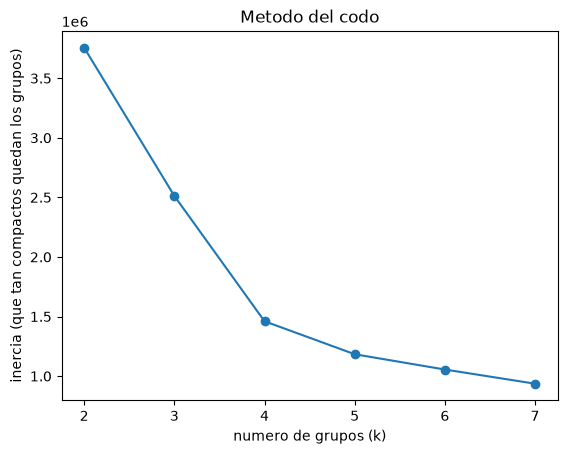

In [6]:
inercias = []
valores_k = range(2, 8)

for k in valores_k:
    modelo_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_prueba.fit(datos_escalados)
    inercias.append(modelo_prueba.inertia_)

plt.plot(list(valores_k), inercias, marker='o')
plt.xlabel('numero de grupos (k)')
plt.ylabel('inercia (que tan compactos quedan los grupos)')
plt.title('Metodo del codo')
plt.show()

**Decisión:** dentro del rango de 3 a 5, se usan **4 grupos** — un punto intermedio que da
suficiente detalle para contar una historia de negocio clara (más que 3) sin volverse
difícil de comunicar (menos que 5).

In [7]:
k_elegido = 4

modelo_cluster = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
clusters_normales = modelo_cluster.fit_predict(datos_escalados)

# a los clientes normales les asignamos su grupo (0 a k_elegido-1);
# a los atipicos les asignamos -1, para que queden identificados aparte
cliente_360['cluster'] = -1
cliente_360.loc[~cliente_360['patrimonio_atipico'], 'cluster'] = clusters_normales

cliente_360['cluster'].value_counts().sort_index()

cluster
-1        68
 0    574503
 1     11382
 2    145150
 3    128693
Name: count, dtype: int64

## 4. ¿Cómo es cada grupo? (ponerles nombre)

Miramos el perfil promedio de cada grupo en las variables originales (sin escalar, para
que los números tengan unidades que se entiendan) y les ponemos un nombre de negocio según
lo que veamos.

In [8]:
clientes_normales = cliente_360[cliente_360['cluster'] != -1]

perfil_clusters = clientes_normales.groupby('cluster')[columnas_para_agrupar].median()
perfil_clusters['numero_de_clientes'] = clientes_normales['cluster'].value_counts().sort_index()
perfil_clusters

,ingresos_mensuales,total_patrimonio,total_egresos_mensuales,edad_numerica,numero_de_productos,numero_de_clientes
cluster,,,,,,
0,"2,500,000.00","19,733,000.00","500,000.00",42.50,1.00,574503
1,0.00,0.00,0.00,42.50,0.00,11382
2,"1,505,050.00",0.00,"500,000.00",30.50,0.00,145150
3,"1,739,747.00","3,970,337.00",0.00,42.50,1.00,128693


Con la tabla de arriba, se le puso nombre a cada grupo según su perfil real:

- **Grupo 0 — Base consolidada con patrimonio**: el más grande, mayor patrimonio e ingreso
  de los 4, con al menos 1 producto.
- **Grupo 1 — Clientes sin huella financiera visible**: ingreso, patrimonio, egresos y
  productos en cero — relación muy delgada o inactiva con el banco.
- **Grupo 2 — Jóvenes en etapa inicial**: se distingue por ser claramente más joven (30.5
  años vs 42.5 en los demás grupos), sin patrimonio ni productos todavía.
- **Grupo 3 — Clientes en construcción de patrimonio**: parecido al grupo 0, pero con
  bastante menos patrimonio — construyendo, no consolidado todavía.

In [9]:
nombres_cluster = {
    -1: 'Patrimonio atipico (revisar aparte)',
    0: 'Base consolidada con patrimonio',
    1: 'Clientes sin huella financiera visible',
    2: 'Jovenes en etapa inicial',
    3: 'Clientes en construccion de patrimonio',
}

cliente_360['nombre_cluster'] = cliente_360['cluster'].map(nombres_cluster)
cliente_360[['cluster', 'nombre_cluster']].drop_duplicates().sort_values('cluster')

,cluster,nombre_cluster
4334,-1,Patrimonio atipico (revisar aparte)
0,0,Base consolidada con patrimonio
302,1,Clientes sin huella financiera visible
5,2,Jovenes en etapa inicial
3,3,Clientes en construccion de patrimonio


## 5. Visualizar los grupos

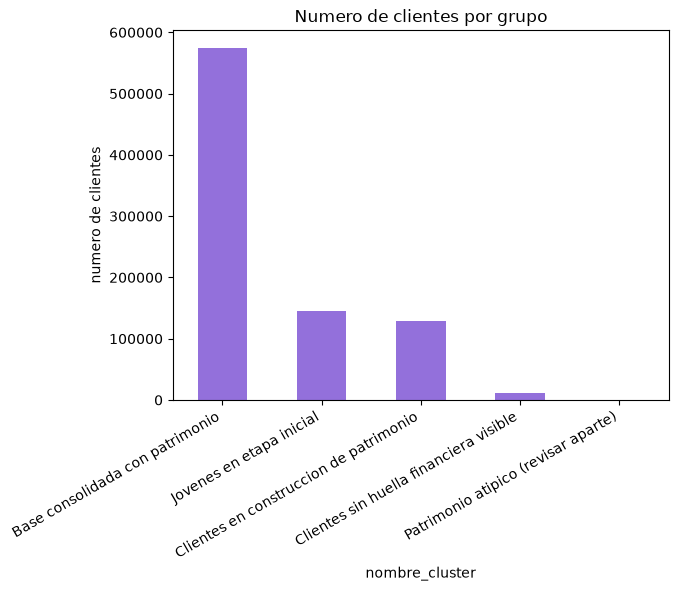

In [10]:
cliente_360['nombre_cluster'].value_counts().plot(
    kind='bar', title='Numero de clientes por grupo', color='mediumpurple'
)
plt.ylabel('numero de clientes')
plt.xticks(rotation=30, ha='right')
plt.show()

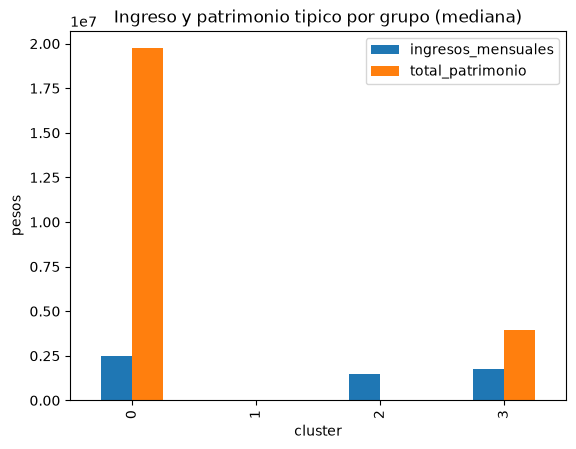

In [11]:
perfil_clusters[['ingresos_mensuales', 'total_patrimonio']].plot(
    kind='bar', title='Ingreso y patrimonio tipico por grupo (mediana)'
)
plt.ylabel('pesos')
plt.show()

## 6. Guardar el resultado

In [12]:
resultado = cliente_360[['numero_id', 'cluster', 'nombre_cluster']]
resultado.to_csv('../04_Resultados/clusters.csv', index=False)
print('Guardado:', len(resultado), 'clientes con su grupo asignado')

Guardado: 859796 clientes con su grupo asignado
